In [17]:
!pip uninstall -y torch torchvision torchaudio
!pip install --index-url https://download.pytorch.org/whl/cu121 torch torchvision torchaudio

Found existing installation: torch 2.1.0+cu118
Uninstalling torch-2.1.0+cu118:
  Successfully uninstalled torch-2.1.0+cu118
Found existing installation: torchvision 0.16.0+cu118
Uninstalling torchvision-0.16.0+cu118:
  Successfully uninstalled torchvision-0.16.0+cu118
Found existing installation: torchaudio 2.1.0+cu118
Uninstalling torchaudio-2.1.0+cu118:
  Successfully uninstalled torchaudio-2.1.0+cu118
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp310-cp310-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp310-cp310-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp310-cp310-win_amd64.whl (4.1 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ----------

In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.5.1+cu121
CUDA available: True
Device count: 1
GPU name: NVIDIA GeForce GTX 1650


In [2]:
import os
import json
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [3]:
print(os.listdir('plantvillage dataset'))

['color', 'grayscale', 'segmented']


In [4]:
# Dataset path
BASE_DIR = "./plantvillage dataset/color"

In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20
TRAIN_SPLIT = 0.8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Image transforms
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [7]:
# Prepare dataset and train/validation split
full_dataset = datasets.ImageFolder(BASE_DIR, transform=transform)
train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Train samples: {len(train_dataset)}")

Train samples: 43444


In [8]:
# Validation loader
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Validation samples: {len(val_dataset)}")

Validation samples: 10861


In [9]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        flattened_size = 128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, len(full_dataset.classes))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = PlantDiseaseCNN(num_classes=len(full_dataset.classes)).to(device)

In [10]:
print(model)

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=38, bias=True)
  )
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] Train Loss: 1.2859, Train Acc: 0.6282, Val Loss: 0.6736, Val Acc: 0.7890
Epoch [2/20] Train Loss: 0.6424, Train Acc: 0.7958, Val Loss: 0.3595, Val Acc: 0.8877
Epoch [3/20] Train Loss: 0.4634, Train Acc: 0.8515, Val Loss: 0.3909, Val Acc: 0.8763
Epoch [4/20] Train Loss: 0.3445, Train Acc: 0.8873, Val Loss: 0.2678, Val Acc: 0.9181
Epoch [5/20] Train Loss: 0.2753, Train Acc: 0.9090, Val Loss: 0.3275, Val Acc: 0.8949
Epoch [6/20] Train Loss: 0.2252, Train Acc: 0.9256, Val Loss: 0.2973, Val Acc: 0.9121
Epoch [7/20] Train Loss: 0.1867, Train Acc: 0.9370, Val Loss: 0.3868, Val Acc: 0.8988
Epoch [8/20] Train Loss: 0.1604, Train Acc: 0.9459, Val Loss: 0.2514, Val Acc: 0.9313
Epoch [9/20] Train Loss: 0.1439, Train Acc: 0.9528, Val Loss: 0.2883, Val Acc: 0.9247
Epoch [10/20] Train Loss: 0.1214, Train Acc: 0.9587, Val Loss: 0.3076, Val Acc: 0.9250
Epoch [11/20] Train Loss: 0.1147, Train Acc: 0.9618, Val Loss: 0.3426, Val Acc: 0.9198
Epoch [12/20] Train Loss: 0.1017, Train Acc: 0.9649,

## Model Evulation

In [19]:
model.eval()
val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_acc = val_correct / val_total

print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)

Validation loss: 0.41996683884494285
Validation accuracy: 0.9232114906546358


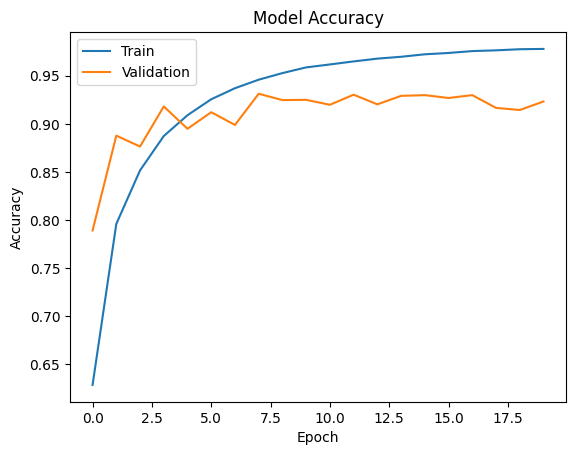

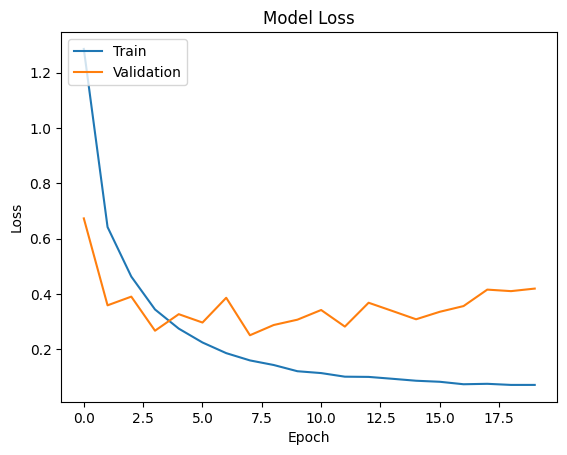

In [20]:
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [21]:
def load_and_process(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert("RGB")
    infer_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
    ])
    tensor = infer_transform(img).unsqueeze(0)
    return tensor.to(device)

In [22]:
def predict_image(model, image_path, class_indices):
    model.eval()
    preprocessed_image = load_and_process(image_path)

    with torch.no_grad():
        prediction = model(preprocessed_image)
        predicted_class_index = torch.argmax(prediction, dim=1).item()

    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [23]:
# Create a mapping for class indices
class_indices = {idx: class_name for idx, class_name in enumerate(full_dataset.classes)}
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [24]:
json.dump(class_indices,open('class_indices.json','w'))

In [27]:
image_path = "./temp_image.jpg"  # Replace with your test image path
predicted_class = predict_image(model, image_path, class_indices)
print(predicted_class)

Pepper,_bell___healthy


In [26]:
# Save model weights
torch.save(model.state_dict(), "plant_model.pth")
print("Model saved as plant_model.pth")

Model saved as plant_model.pth
